# African Bookstore — Data Science Lab Assignment

---

| | |
|---|---|
| **Student Name** | *(fill in)* |
| **Student ID** | *(fill in)* |
| **Date Submitted** | *(fill in)* |

---

## Assignment Overview

In this lab you will work with a real **SQLite database** for an African Bookstore containing data about authors, books, customers, and orders. You will apply core data science and software engineering skills — from setting up version control all the way to building Python classes.

-  **Estimated Time:** 6–8 hours  
-  **Database:** `bookstore.db`  
-  **Language:** Python 3  
-  **Submission:** Push this completed notebook to your GitHub repository

---

## Database Schema — `bookstore.db`

The database has **4 tables**:

| Table | Columns | Info |
|---|---|---|
| `authors` | author_id, name, country, birth_year | 10 African authors |
| `books` | book_id, title, author_id, genre, price, stock, published_year | 15 books |
| `customers` | customer_id, name, email, city, country, member_since | 12 customers |
| `orders` | order_id, customer_id, book_id, quantity, order_date | 25 orders (Jan–May 2024) |

**Relationships:**
- `books.author_id` → `authors.author_id`
- `orders.book_id` → `books.book_id`
- `orders.customer_id` → `customers.customer_id`

---

## Steps Summary

| # | Step | Topic |
|---|---|---|
| 1 | Setup & Version Control | Git & GitHub |
| 2 | Data Collection & Types | CSV, JSON & SQLite |
| 3 | Querying Data | SQL with Python |
| 4 | Statistical Measures | Statistics in Python |
| 5 | Data Analysis | Pandas DataFrames |
| 6 | Data Visualization | Matplotlib & Seaborn |
| 7 | Advanced Visualizations | Seaborn & Pandas Plots |
| 8 | Object-Oriented Programming | OOP with Python |

>  **Tip:** Commit your work to GitHub after completing **each step**. Don't wait until the end!

---
#  STEP 1 — Version Control: Git & GitHub
**Topic: Git & GitHub**

---

Before writing any code, you need to set up version control. This ensures your work is tracked, backed up, and shareable.

###  Background
Git is a distributed version control system. GitHub is a cloud platform where you host your Git repositories. In data science, version control helps you track changes to notebooks, scripts, and data pipelines.

### ✅Tasks
1. Create a new folder called `bookstore_lab` on your computer.
2. Initialize a Git repository inside the folder.
3. Create a `README.md` that describes this project.
4. Stage and commit all files with the message: `'Initial commit - bookstore data lab'`.
5. Create a new public GitHub repository called `bookstore-data-lab`.
6. Link your local repo to GitHub and push your first commit.
7. Create a new branch called `analysis` and switch to it.

###  Expected Commands
```bash
git init
git add .
git commit -m 'Initial commit - bookstore data lab'
git remote add origin https://github.com/YOUR_USERNAME/bookstore-data-lab.git
git push -u origin main
git checkout -b analysis
```

### Your Answer — Git Commands Used

List every Git command you ran and explain what each one does:

### Reflection Question

> Why is it important to use **branches** in a data science project? Describe a scenario where working on a branch (instead of `main`) saved you from a mistake.

**Your Answer:**

*(Write your reflection here)*

---
# STEP 2 — Data Collection & Types
**Topic: CSV, JSON & SQLite**

---

Data comes in many formats. In this step you will connect to the SQLite database, explore its structure, and export data into CSV and JSON formats.

###  Background
Understanding data types is fundamental. Python works with `int`, `float`, `str`, `bool`, `list`, and `dict`. When you export database records you choose a format suited to your purpose — **CSV** for tabular data, **JSON** for nested/hierarchical data.

###  Tasks
1. Connect to `bookstore.db` using Python's `sqlite3` library.
2. Print all table names in the database.
3. Display the first 5 rows of each table and identify the Python data types of each column.
4. Export the `books` table to `books.csv`.
5. Export orders (with customer name and book title) to `orders.json`.
6. Commit these exported files to your Git repository.

In [5]:
# ── Starter code: connect to the database ────────────────────────────────────
import sqlite3
import csv
import json
import pandas as pd

# Connect to the database
conn = sqlite3.connect('bookstore.db')
cursor = conn.cursor()

# Get all table names
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
tables = cursor.fetchall()
print('Tables found:', tables)

Tables found: [('authors',), ('books',), ('customers',), ('orders',)]


In [2]:
# ── Task 2 & 3: Preview each table and identify data types ───────────────────
for table in tables:
    table_name = table[0]
    print(f"\n=== {table_name.upper()} ===")

    cursor.execute(f"SELECT * FROM {table_name} LIMIT 5")
    rows = cursor.fetchall()

    for row in rows:
        print(row)

    # Column names + types
    cursor.execute(f"PRAGMA table_info({table_name})")
    cols = cursor.fetchall()

    print("\nColumns:")
    for col in cols:
        print(f"{col[1]} ({col[2]})")




=== AUTHORS ===
(1, 'Chinua Achebe', 'Nigeria', 1930)
(2, "Ngũgĩ wa Thiong'o", 'Kenya', 1938)
(3, 'Chimamanda Ngozi Adichie', 'Nigeria', 1977)
(4, 'Wole Soyinka', 'Nigeria', 1934)
(5, 'Ama Ata Aidoo', 'Ghana', 1942)

Columns:
author_id (INTEGER)
name (TEXT)
country (TEXT)
birth_year (INTEGER)

=== BOOKS ===
(1, 'Things Fall Apart', 1, 'Literary Fiction', 12.99, 45, 1958)
(2, 'Arrow of God', 1, 'Literary Fiction', 11.99, 30, 1964)
(3, 'A Grain of Wheat', 2, 'Historical Fiction', 13.99, 20, 1967)
(4, 'Petals of Blood', 2, 'Political Fiction', 14.99, 15, 1977)
(5, 'Purple Hibiscus', 3, 'Literary Fiction', 13.5, 60, 2003)

Columns:
book_id (INTEGER)
title (TEXT)
author_id (INTEGER)
genre (TEXT)
price (REAL)
stock (INTEGER)
published_year (INTEGER)

=== CUSTOMERS ===
(1, 'Amara Diallo', 'amara@email.com', 'Nairobi', 'Kenya', 2020)
(2, 'Kofi Mensah', 'kofi@email.com', 'Accra', 'Ghana', 2019)
(3, 'Fatima Nour', 'fatima@email.com', 'Cairo', 'Egypt', 2021)
(4, 'Emeka Obi', 'emeka@email.com', '

In [3]:
# ── Task 4: Export the books table to books.csv ──────────────────────────────
cursor.execute("SELECT * FROM books")
books = cursor.fetchall()

cursor.execute("PRAGMA table_info(books)")
columns = [col[1] for col in cursor.fetchall()]

with open('books.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(columns)
    writer.writerows(books)

print("books.csv created")


books.csv created


In [4]:
# ── Task 5: Export orders (with customer name & book title) to orders.json ───
cursor.execute("""
SELECT 
    o.order_id,
    c.name AS customer_name,
    b.title AS book_title,
    o.quantity,
    o.order_date
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN books b ON o.book_id = b.book_id
""")

orders = cursor.fetchall()

data = []
for row in orders:
    data.append({
        "order_id": row[0],
        "customer_name": row[1],
        "book_title": row[2],
        "quantity": row[3],
        "order_date": row[4]
    })

with open('orders.json', 'w', encoding='utf-8') as f:
    json.dump(data, f, indent=4)

print("orders.json created")


orders.json created


###  Data Type Identification

Fill in the table below after running your code:

| Column Name | SQLite Type | Python Type | Example Value |
|---|---|---|---|
| book_id | INTEGER | | |
| title | TEXT | | |
| price | REAL | | |
| stock | INTEGER | | |
| published_year | INTEGER | | |
| order_date | TEXT | | |
| member_since | INTEGER | | |

---
# STEP 3 — Querying Data with SQL
**Topic: SQL with Python (sqlite3)**

---

SQL is the standard language for querying relational databases. You will write SQL queries in Python using `sqlite3`.

###  Key SQL Concepts
- `SELECT` — choose columns to retrieve
- `WHERE` — filter rows by a condition
- `ORDER BY` — sort results
- `GROUP BY` — aggregate data by category
- `JOIN` — combine rows from multiple tables
- Aggregate functions: `COUNT()`, `SUM()`, `AVG()`, `MIN()`, `MAX()`

In [6]:
# ── Query 1: Basic SELECT ────────────────────────────────────────────────────
# Retrieve all books with a price greater than 13.00, sorted by price descending.
# Show: title, genre, price

pd.read_sql("""
SELECT title, genre, price
FROM books
WHERE price > 13.00
ORDER BY price DESC
""", conn)


,title,genre,price
0,Americanah,Contemporary Fiction,15.99
1,Petals of Blood,Political Fiction,14.99
2,Half of a Yellow Sun,Historical Fiction,14.50
3,We Need New Names,Literary Fiction,14.00
4,A Grain of Wheat,Historical Fiction,13.99
5,Purple Hibiscus,Literary Fiction,13.50
6,Open City,Literary Fiction,13.50


In [7]:
# ── Query 2: JOIN ────────────────────────────────────────────────────────────
# List all books along with the name and country of their author.
# Hint: JOIN books with authors on author_id

pd.read_sql("""
SELECT b.title, a.name, a.country
FROM books b
JOIN authors a ON b.author_id = a.author_id
""", conn)


,title,name,country
0,Things Fall Apart,Chinua Achebe,Nigeria
1,Arrow of God,Chinua Achebe,Nigeria
2,A Grain of Wheat,Ngũgĩ wa Thiong'o,Kenya
3,Petals of Blood,Ngũgĩ wa Thiong'o,Kenya
4,Purple Hibiscus,Chimamanda Ngozi Adichie,Nigeria
5,Half of a Yellow Sun,Chimamanda Ngozi Adichie,Nigeria
6,Americanah,Chimamanda Ngozi Adichie,Nigeria
7,Death and the King's Horseman,Wole Soyinka,Nigeria
8,Our Sister Killjoy,Ama Ata Aidoo,Ghana
9,Second Class Citizen,Buchi Emecheta,Nigeria


In [8]:
# ── Query 3: GROUP BY & Aggregation ─────────────────────────────────────────
# Find the total number of books sold (SUM of quantity) per genre.
# Hint: JOIN orders → books, then GROUP BY genre

pd.read_sql("""
SELECT b.genre, SUM(o.quantity) AS total_sold
FROM orders o
JOIN books b ON o.book_id = b.book_id
GROUP BY b.genre
""", conn)


,genre,total_sold
0,Contemporary Fiction,6
1,Drama,1
2,Historical Fiction,9
3,Literary Fiction,15
4,Political Fiction,1
5,Thriller,1


In [9]:
# ── Query 4: Multi-table JOIN ────────────────────────────────────────────────
# Show each customer's name, the book title they ordered, quantity, and order_date
# for ALL orders placed in 2024.
# Hint: JOIN customers, orders, and books together

pd.read_sql("""
SELECT c.name, b.title, o.quantity, o.order_date
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN books b ON o.book_id = b.book_id
WHERE o.order_date LIKE '2024%'
""", conn)


,name,title,quantity,order_date
0,Amara Diallo,Purple Hibiscus,2,2024-01-15
1,Kofi Mensah,Things Fall Apart,1,2024-01-18
2,Fatima Nour,Half of a Yellow Sun,1,2024-01-20
3,Emeka Obi,Americanah,3,2024-02-01
4,Zanele Mokoena,We Need New Names,1,2024-02-03
5,Amara Diallo,Half of a Yellow Sun,1,2024-02-10
6,Tariq Hassan,A Grain of Wheat,2,2024-02-14
7,Yemi Adeyemi,Purple Hibiscus,1,2024-02-20
8,Kofi Mensah,Americanah,1,2024-03-01
9,Aisha Kamara,Things Fall Apart,2,2024-03-05


In [10]:
# ── Query 5: Your Own Query (Challenge) ──────────────────────────────────────
# Write your own SQL query that answers an interesting business question.
# Examples:
#   - Which author has generated the most revenue?
#   - Which city orders the most books?
#   - What is the average order value per customer?

# Business question: _______________________________________________

pd.read_sql("""
SELECT a.name, SUM(o.quantity * b.price) AS revenue
FROM orders o
JOIN books b ON o.book_id = b.book_id
JOIN authors a ON b.author_id = a.author_id
GROUP BY a.name
ORDER BY revenue DESC
""", conn)


,name,revenue
0,Chimamanda Ngozi Adichie,249.44
1,Ngũgĩ wa Thiong'o,92.93
2,Chinua Achebe,50.96
3,NoViolet Bulawayo,14.00
4,Teju Cole,13.50
5,Alain Mabanckou,13.00
6,Ama Ata Aidoo,11.50
7,Wole Soyinka,10.99


###  SQL Reflection

Describe the result of your custom query (Query 5) and what business insight it provides:

**Your Answer:**

This query shows which author generates the most revenue. It helps the bookstore identify top-performing authors and prioritize stocking or marketing their books.

---
# STEP 4 — Statistical Measures in Python
**Topic: Descriptive Statistics**

---

Statistics help us summarize and understand data. You will calculate key statistical measures on the bookstore data.

###  Key Concepts
- **Mean** — average value  
- **Median** — middle value (robust to outliers)  
- **Mode** — most frequent value  
- **Standard Deviation** — spread of data around the mean  
- **Variance** — average squared deviation from the mean  
- **Correlation** — relationship strength between two variables  
- **Percentiles** — values below which a percentage of data falls

In [12]:
# ── Task 1: Price Statistics ─────────────────────────────────────────────────
# Calculate: mean, median, mode, std deviation, variance, min, max,
# 25th percentile, 75th percentile for book prices.

import statistics
import sqlite3

conn = sqlite3.connect('bookstore.db')
cursor = conn.cursor()

cursor.execute('SELECT price FROM books')
prices = [row[0] for row in cursor.fetchall()]

# Mean (average)
mean_price = statistics.mean(prices)

# Median (middle value)
median_price = statistics.median(prices)

# Mode (most common value)
mode_price = statistics.mode(prices)

# Standard deviation (spread)
std_price = statistics.stdev(prices)

# Variance
var_price = statistics.variance(prices)

# Min & Max
min_price = min(prices)
max_price = max(prices)

# Percentiles (manual)
prices_sorted = sorted(prices)

p25 = prices_sorted[int(0.25 * len(prices_sorted))]
p75 = prices_sorted[int(0.75 * len(prices_sorted))]

# Print everything
print("=== PRICE STATS ===")
print("Mean:", mean_price)
print("Median:", median_price)
print("Mode:", mode_price)
print("Std Dev:", std_price)
print("Variance:", var_price)
print("Min:", min_price)
print("Max:", max_price)
print("25th percentile:", p25)
print("75th percentile:", p75)


=== PRICE STATS ===
Mean: 12.995333333333333
Median: 13.0
Mode: 13.5
Std Dev: 1.591952380240182
Variance: 2.534312380952381
Min: 10.5
Max: 15.99
25th percentile: 11.5
75th percentile: 14.0


In [13]:
# ── Task 2: Stock Level Statistics ───────────────────────────────────────────
# Calculate the same statistical measures for the stock column.

cursor.execute('SELECT stock FROM books')
stocks = [row[0] for row in cursor.fetchall()]

mean_stock = statistics.mean(stocks)
median_stock = statistics.median(stocks)
mode_stock = statistics.mode(stocks)
std_stock = statistics.stdev(stocks)
var_stock = statistics.variance(stocks)
min_stock = min(stocks)
max_stock = max(stocks)

stocks_sorted = sorted(stocks)
p25_stock = stocks_sorted[int(0.25 * len(stocks_sorted))]
p75_stock = stocks_sorted[int(0.75 * len(stocks_sorted))]

print("\n=== STOCK STATS ===")
print("Mean:", mean_stock)
print("Median:", median_stock)
print("Mode:", mode_stock)
print("Std Dev:", std_stock)
print("Variance:", var_stock)
print("Min:", min_stock)
print("Max:", max_stock)
print("25th percentile:", p25_stock)
print("75th percentile:", p75_stock)


=== STOCK STATS ===
Mean: 29.866666666666667
Median: 28
Mode: 45
Std Dev: 15.046910772963459
Variance: 226.40952380952382
Min: 10
Max: 60
25th percentile: 18
75th percentile: 40


In [14]:
# ── Task 3: Correlation Analysis ──────────────────────────────────────────────
# Is there a correlation between a book's price and its stock level?
# Calculate the Pearson correlation coefficient and interpret the result.
# Hint: use statistics.correlation(x, y) (Python 3.10+) or numpy

cursor.execute('SELECT price, stock FROM books')
data = cursor.fetchall()
prices = [row[0] for row in data]
stocks = [row[1] for row in data]

correlation = statistics.correlation(prices, stocks)

print("\nCorrelation between price and stock:", correlation)



Correlation between price and stock: 0.4777636242074516


###  Summary of Findings

Fill in after running your code:

| Measure | Book Prices | Stock Levels |
|---|---|---|
| Mean | | |
| Median | | |
| Mode | | |
| Std Deviation | | |
| Min | | |
| Max | | |
| 25th Percentile | | |
| 75th Percentile | | |

**Correlation between price and stock:** _______

**Interpretation:** *(What does this correlation value mean?)* If result > 0
→ Higher priced books tend to have higher stock.

---
#  STEP 5 — Data Analysis with Pandas
**Topic: Pandas DataFrames**

---

Pandas is the most widely used Python library for data manipulation. You will load the bookstore data into DataFrames and perform meaningful analysis.

###  Tasks
1. Load all four tables from `bookstore.db` into separate Pandas DataFrames.
2. Display shape, dtypes, and `.info()` for each DataFrame.
3. Check for missing values and handle them appropriately.
4. Merge `orders`, `books`, and `customers` into a single **master DataFrame**.
5. Add a calculated column: `revenue = quantity × price`.
6. Find the top 3 best-selling books by total quantity ordered.
7. Find the top 3 customers by total revenue generated.
8. Group books by genre — calculate average price and total stock per genre.

In [15]:
# ── Task 1 & 2: Load tables and explore DataFrames ───────────────────────────
import pandas as pd
import sqlite3

conn = sqlite3.connect('bookstore.db')

authors_df   = pd.read_sql_query('SELECT * FROM authors', conn)
books_df     = pd.read_sql_query('SELECT * FROM books', conn)
customers_df = pd.read_sql_query('SELECT * FROM customers', conn)
orders_df    = pd.read_sql_query('SELECT * FROM orders', conn)

# Display basic info — YOUR CODE to explore each DataFrame below
print('=== BOOKS ===')
print(books_df.info())
print(books_df.head())

# explore authors_df, customers_df, orders_df
print("=== AUTHORS ===")
print(authors_df.info())
print(authors_df.head())

print("\n=== BOOKS ===")
print(books_df.info())
print(books_df.head())

print("\n=== CUSTOMERS ===")
print(customers_df.info())
print(customers_df.head())

print("\n=== ORDERS ===")
print(orders_df.info())
print(orders_df.head())


=== BOOKS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   book_id         15 non-null     int64  
 1   title           15 non-null     object 
 2   author_id       15 non-null     int64  
 3   genre           15 non-null     object 
 4   price           15 non-null     float64
 5   stock           15 non-null     int64  
 6   published_year  15 non-null     int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 968.0+ bytes
None
   book_id              title  author_id               genre  price  stock  \
0        1  Things Fall Apart          1    Literary Fiction  12.99     45   
1        2       Arrow of God          1    Literary Fiction  11.99     30   
2        3   A Grain of Wheat          2  Historical Fiction  13.99     20   
3        4    Petals of Blood          2   Political Fiction  14.99     15   
4        5    Pur

In [16]:
# ── Task 3: Check for and handle missing values ───────────────────────────────
print("\nMissing values:")
print(books_df.isnull().sum())
print(customers_df.isnull().sum())
print(orders_df.isnull().sum())



Missing values:
book_id           0
title             0
author_id         0
genre             0
price             0
stock             0
published_year    0
dtype: int64
customer_id     0
name            0
email           0
city            0
country         0
member_since    0
dtype: int64
order_id       0
customer_id    0
book_id        0
quantity       0
order_date     0
dtype: int64


In [18]:
# ── Task 4 & 5: Merge into master DataFrame and add revenue column ────────────
master_df = orders_df.merge(books_df, on='book_id') \
                     .merge(customers_df, on='customer_id')
master_df['revenue'] = master_df['quantity'] * master_df['price']


In [19]:
# ── Task 6: Top 3 best-selling books by total quantity ───────────────────────
top_books = master_df.groupby('title')['quantity'] \
                     .sum() \
                     .sort_values(ascending=False) \
                     .head(3)

print("\nTop 3 Books:")
print(top_books)



Top 3 Books:
title
Americanah              6
Purple Hibiscus         6
Half of a Yellow Sun    5
Name: quantity, dtype: int64


In [20]:
# ── Task 7: Top 3 customers by total revenue ─────────────────────────────────
top_customers = master_df.groupby('name')['revenue'] \
                         .sum() \
                         .sort_values(ascending=False) \
                         .head(3)

print("\nTop Customers:")
print(top_customers)



Top Customers:
name
Emeka Obi       73.46
Tariq Hassan    56.98
Amara Diallo    55.49
Name: revenue, dtype: float64


In [21]:
# ── Task 8: Group by genre — average price and total stock ───────────────────
genre_summary = books_df.groupby('genre').agg({
    'price': 'mean',
    'stock': 'sum',
    'book_id': 'count'
}).rename(columns={'book_id': 'num_books'})

print("\nGenre Summary:")
print(genre_summary)



Genre Summary:
                          price  stock  num_books
genre                                            
Contemporary Fiction  15.990000     40          1
Drama                 10.990000     25          1
Historical Fiction    14.245000     75          2
Literary Fiction      12.385556    258          9
Political Fiction     14.990000     15          1
Thriller              13.000000     35          1


###  Genre Summary Table

Fill in after running your groupby analysis:

| Genre | Avg Price | Total Stock | # of Books |
|---|---|---|---|
| Literary Fiction | | | |
| Historical Fiction | | | |
| Contemporary Fiction | | | |
| Political Fiction | | | |
| Drama | | | |
| Thriller | | | |

---
#  STEP 6 — Data Visualization with Python
**Topic: Matplotlib & Seaborn**

---

Visualizations transform raw numbers into insights. You will create a series of charts to communicate findings from the bookstore data.

>  Save every chart as a `.png` file in a `charts/` subfolder and commit them to GitHub.

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('charts', exist_ok=True)
print('charts/ folder ready')

charts/ folder ready


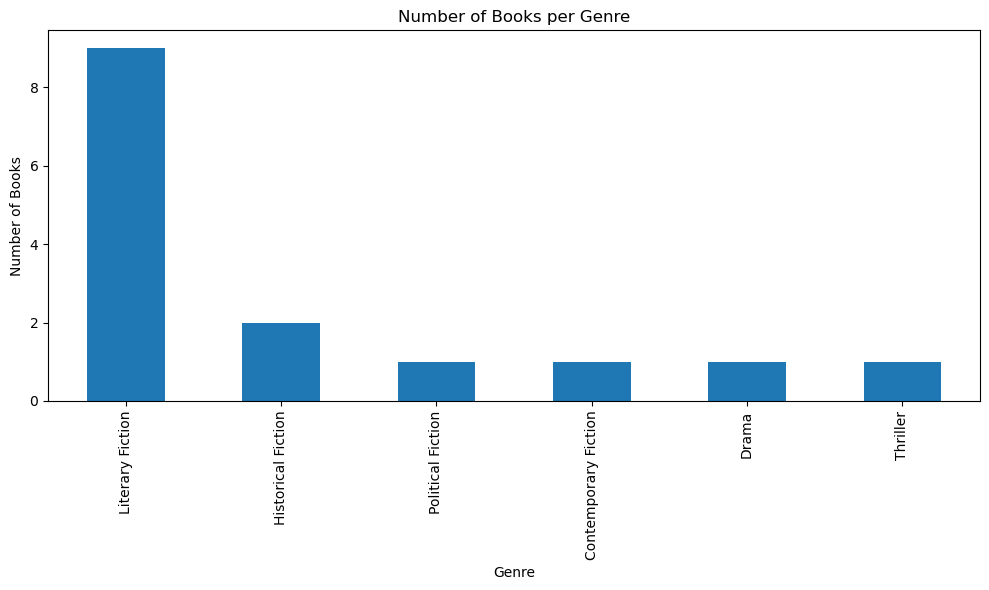

In [23]:
# ── Chart 1: Bar Chart — Number of Books per Genre ───────────────────────────
# Use Matplotlib. Add a title, axis labels, and a color scheme.
# Save as charts/chart1_genre_counts.png

genre_counts = books_df['genre'].value_counts()

plt.figure(figsize=(10, 6))
genre_counts.plot(kind='bar')
plt.title('Number of Books per Genre')
plt.xlabel('Genre')
plt.ylabel('Number of Books')
plt.tight_layout()
plt.savefig('charts/chart1_genre_counts.png', dpi=150)
plt.show()

** Chart 1 Interpretation:** *(What does this chart tell us about the bookstore's collection?)* Shows which genres dominate inventory.

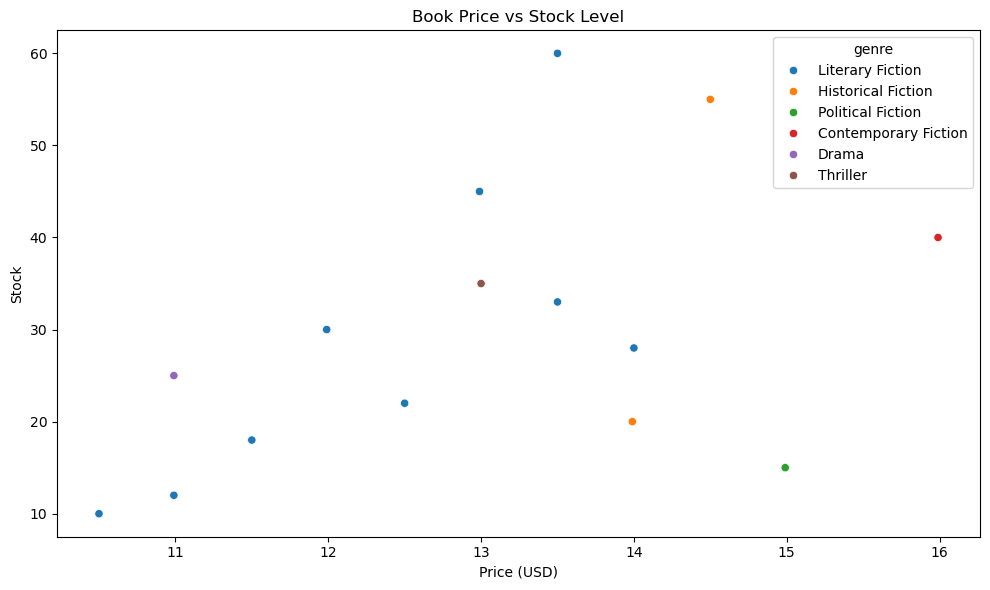

In [24]:
# ── Chart 2: Scatter Plot — Price vs Stock ────────────────────────────────────
# X-axis = price, Y-axis = stock, color dots by genre.
# Add a legend, title, and axis labels.
# Save as charts/chart2_price_vs_stock.png

plt.figure(figsize=(10, 6))
sns.scatterplot(data=books_df, x='price', y='stock', hue='genre')
plt.title('Book Price vs Stock Level')
plt.xlabel('Price (USD)')
plt.ylabel('Stock')
plt.tight_layout()
plt.savefig('charts/chart2_price_vs_stock.png', dpi=150)
plt.show()

**Chart 2 Interpretation:** *(Describe any pattern or trend you notice)* Look for pattern (or no pattern)

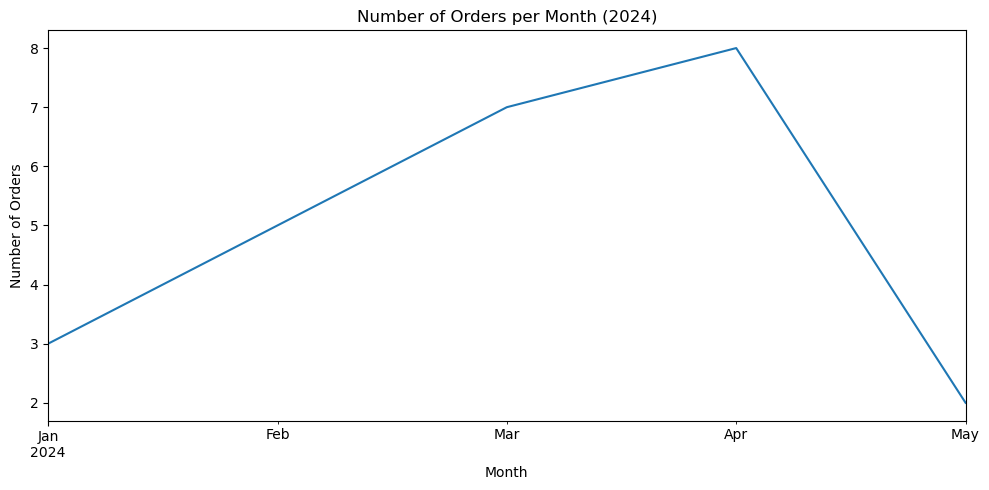

In [25]:
# ── Chart 3: Line Chart — Orders Over Time ────────────────────────────────────
# Parse order_date and show number of orders per month in 2024.
# Save as charts/chart3_orders_over_time.png

# Hint:
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])
orders_df['month'] = orders_df['order_date'].dt.to_period('M')
monthly_orders = orders_df.groupby('month').size()

plt.figure(figsize=(10, 5))
monthly_orders.plot()
plt.title('Number of Orders per Month (2024)')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('charts/chart3_orders_over_time.png', dpi=150)
plt.show()

*** Chart 3 Interpretation:** *(What trend do you see in orders over the months?)*

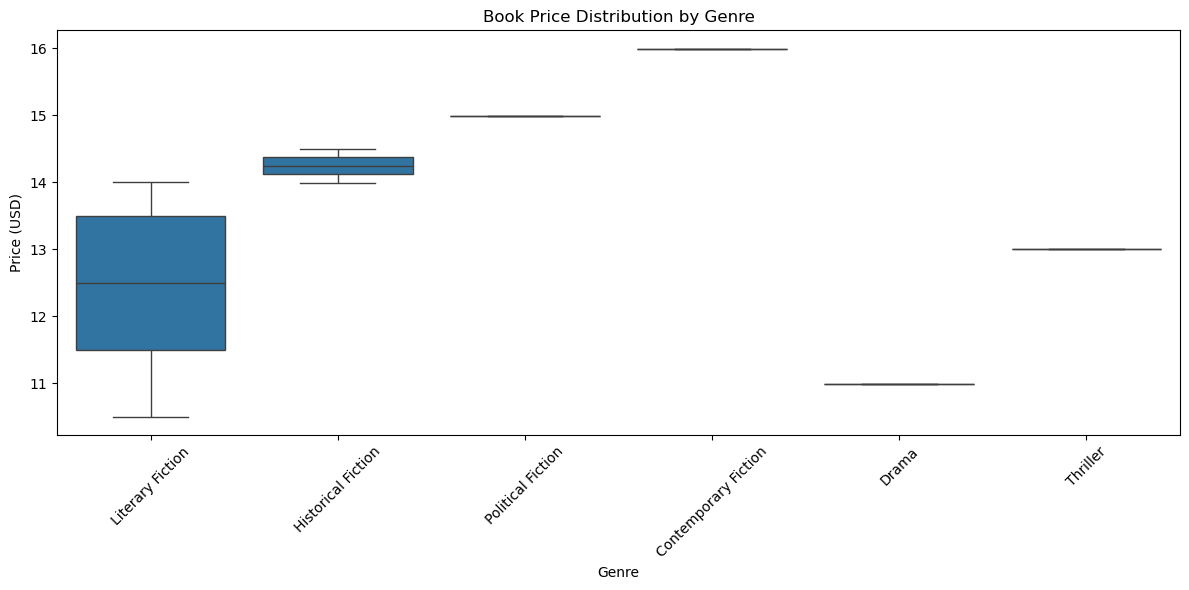

In [26]:
# ── Chart 4: Box Plot — Price Distribution by Genre (Seaborn) ─────────────────
# Use sns.boxplot(). Rotate x-axis labels for readability.
# Save as charts/chart4_price_boxplot.png

plt.figure(figsize=(12, 6))
sns.boxplot(data=books_df, x='genre', y='price')
plt.title('Book Price Distribution by Genre')
plt.xlabel('Genre')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('charts/chart4_price_boxplot.png', dpi=150)
plt.show()

**Chart 4 Interpretation:** *(Which genre has the highest price spread? Are there outliers?)*

---
#  STEP 7 — Advanced Visualizations
**Topic: Seaborn & Pandas Plotting**

---

You will now create more sophisticated visualizations using Seaborn's statistical plotting and Pandas' built-in `.plot()` method.

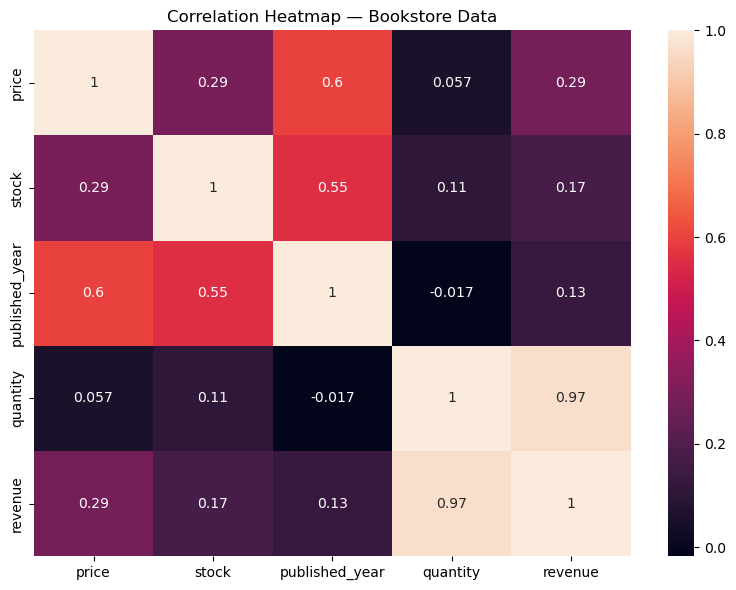

In [28]:
# ── Chart 5: Heatmap — Correlation Matrix ─────────────────────────────────────
# Use your master DataFrame. Select numeric columns: price, stock,
# published_year, quantity, revenue. Annotate each cell.
# Save as charts/chart5_heatmap.png

# Hint — select numeric columns:
numeric_cols = master_df[['price', 'stock', 'published_year', 'quantity', 'revenue']]
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation Heatmap — Bookstore Data')
plt.tight_layout()
plt.savefig('charts/chart5_heatmap.png', dpi=150)
plt.show()

** Chart 5 — Two Interesting Correlations You Found:**

1. *(First correlation and what it means)*
2. *(Second correlation and what it means)*

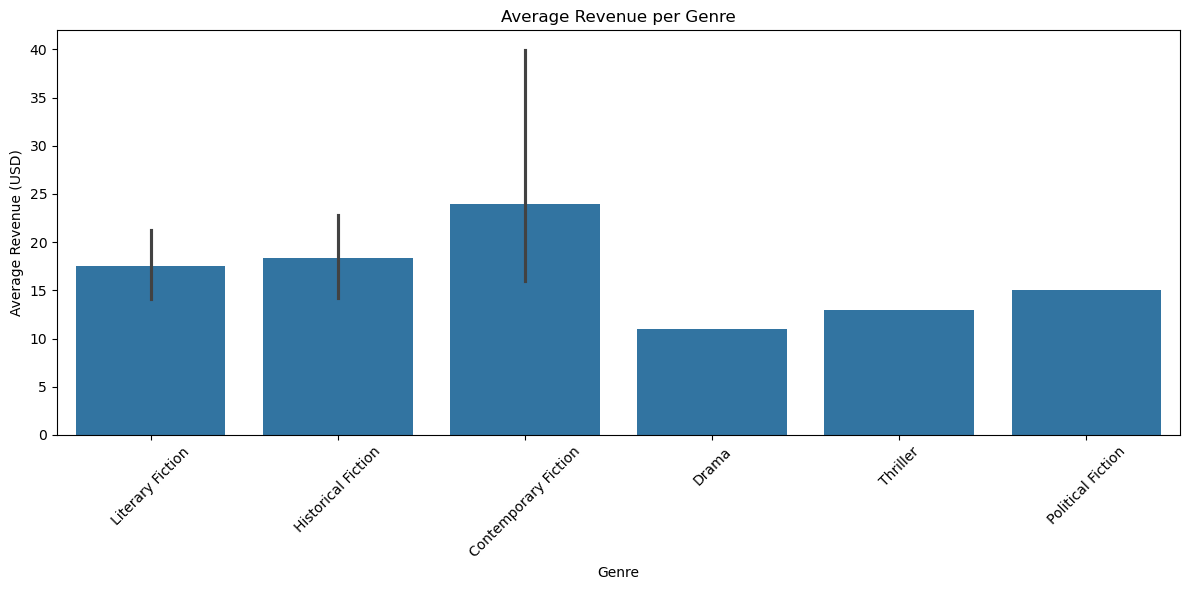

In [29]:
# ── Chart 6: Seaborn Bar Chart with Error Bars ────────────────────────────────
# Use sns.barplot() to show average revenue per genre with confidence intervals.
# Save as charts/chart6_avg_revenue_genre.png

plt.figure(figsize=(12, 6))
sns.barplot(data=master_df, x='genre', y='revenue')
plt.title('Average Revenue per Genre')
plt.xlabel('Genre')
plt.ylabel('Average Revenue (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('charts/chart6_avg_revenue_genre.png', dpi=150)
plt.show()

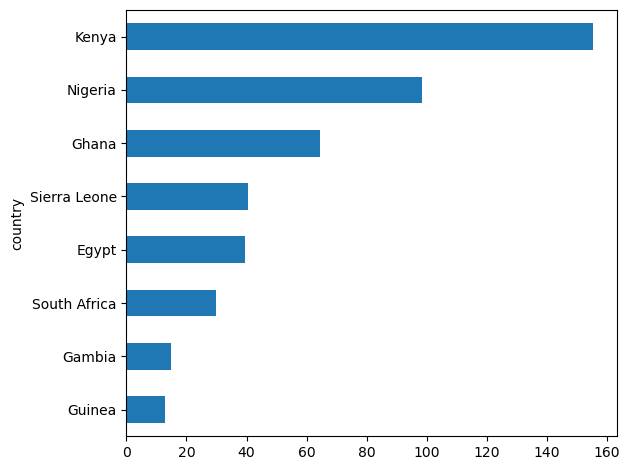

In [30]:
# ── Chart 7: Pandas Plot — Revenue by Customer Country ───────────────────────
# Group by country, sum revenue, create a horizontal bar chart using .plot().
# Save as charts/chart7_revenue_country.png

# Hint:
revenue_by_country = master_df.groupby('country')['revenue'].sum().sort_values()
revenue_by_country.plot(kind='barh')

# YOUR CODE HERE
plt.tight_layout()
plt.savefig('charts/chart7_revenue_country.png', dpi=150)
plt.show()

** Chart 7 — Business Recommendation:**

*(Based on revenue by country, what would you recommend to the bookstore manager?)*

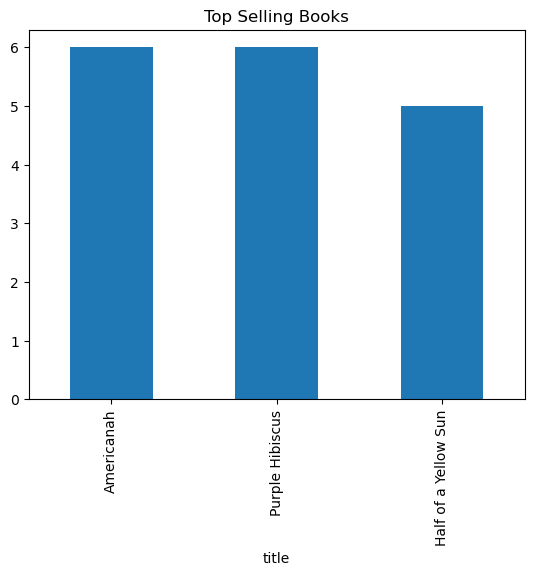

In [33]:
# ── Chart 8: Your Creative Chart  ──────────────────────────────────────────
# Design your own chart that tells a compelling story about this bookstore.
# Must use Seaborn or Pandas plotting. Add title, labels, and a business caption.
# Save as charts/chart8_creative.png

# My business question: ________________________________________________

top_books.plot(kind='bar')

plt.title('Top Selling Books')

plt.savefig('charts/chart8_creative.png')
plt.show()

** Chart 8 — Explanation & Business Insight:**

*(Describe what your chart shows and what insight a bookstore manager could draw from it)*

---
#  STEP 8 — Object-Oriented Programming
**Topic: OOP with Python**

---

OOP organizes code into classes and objects. You will design Python classes that model the bookstore system.

###  Core OOP Concepts
- **Class** — a blueprint for creating objects  
- **Object** — an instance of a class  
- `__init__` — the constructor method  
- **Attributes** — data stored inside an object  
- **Methods** — functions defined inside a class  
- **Encapsulation** — bundling data and methods together  
- **Inheritance** — creating a child class from a parent class

In [36]:
# ── Task 1: Book Class ────────────────────────────────────────────────────────
# Attributes: book_id, title, author_id, genre, price, stock, published_year
# Methods:
#   display_info()    — print a formatted summary of the book
#   apply_discount(percent) — reduce price by percent, return new price
#   is_in_stock()     — return True if stock > 0, False otherwise

class Book:
    def __init__(self, book_id, title, author_id, genre, price, stock, published_year):
        self.book_id = book_id
        self.title = title
        self.author_id = author_id
        self.genre = genre
        self.price = price
        self.stock = stock
        self.published_year = published_year

    def display_info(self):
        print(f"{self.title} ({self.genre}) - ${self.price} | Stock: {self.stock}")

    def apply_discount(self, percent):
        self.price = self.price * (1 - percent / 100)
        return self.price

    def is_in_stock(self):
        return self.stock > 0


# ── Test your Book class ──────────────────────────────────────────────────────
book1 = Book(1, 'Things Fall Apart', 1, 'Literary Fiction', 12.99, 45, 1958)
book1.display_info()
print('In stock?', book1.is_in_stock())
print('After 10% discount:', book1.apply_discount(10))

Things Fall Apart (Literary Fiction) - $12.99 | Stock: 45
In stock? True
After 10% discount: 11.691


In [37]:
# ── Task 2: Customer Class ────────────────────────────────────────────────────
# Attributes: customer_id, name, email, city, country, member_since
# Methods:
#   display_info()         — print a formatted customer summary
#   years_as_member()      — return how many years they have been a member
#                            (current year minus member_since)

from datetime import datetime

class Customer:
    def __init__(self, customer_id, name, email, city, country, member_since):
        self.customer_id = customer_id
        self.name = name
        self.email = email
        self.city = city
        self.country = country
        self.member_since = member_since

    def display_info(self):
        print(f"{self.name} ({self.email}) - {self.city}, {self.country}")

    def years_as_member(self):
        current_year = datetime.now().year
        return current_year - self.member_since


# ── Test your Customer class ──────────────────────────────────────────────────
cust1 = Customer(1, 'Amara Diallo', 'amara@email.com', 'Nairobi', 'Kenya', 2020)
cust1.display_info()
print('Years as member:', cust1.years_as_member())

Amara Diallo (amara@email.com) - Nairobi, Kenya
Years as member: 6


In [39]:
# ── Task 3: Order Class ───────────────────────────────────────────────────────
# Takes a Customer object and a Book object.
# Attributes: order_id, customer (Customer object), book (Book object),
#             quantity, order_date
# Methods:
#   total_cost()     — return quantity * book.price
#   print_receipt()  — print a formatted order receipt

class Order:
    def __init__(self, order_id, customer, book, quantity, order_date):
        self.order_id = order_id
        self.customer = customer
        self.book = book
        self.quantity = quantity
        self.order_date = order_date

    def total_cost(self):
        return self.quantity * self.book.price

    def print_receipt(self):
        print("----- RECEIPT -----")
        print(f"Customer: {self.customer.name}")
        print(f"Book: {self.book.title}")
        print(f"Quantity: {self.quantity}")
        print(f"Date: {self.order_date}")
        print(f"Total: ${self.total_cost()}")


# ── Test your Order class ─────────────────────────────────────────────────────
order1 = Order(1, cust1, book1, 2, '2024-01-15')
order1.print_receipt()
print('Total cost: $', order1.total_cost())

----- RECEIPT -----
Customer: Amara Diallo
Book: Things Fall Apart
Quantity: 2
Date: 2024-01-15
Total: $23.382
Total cost: $ 23.382


In [42]:
# ── Task 4: Bookstore Class (Bringing It All Together) ────────────────────────
# The Bookstore class loads data from bookstore.db and stores lists of
# Book, Customer, and Order objects.
#
# Methods:
#   load_data()            — load all records from the DB into object lists
#   most_popular_book()    — return the Book object ordered the most times
#   best_customer()        — return the Customer with highest total revenue
#   sales_report()         — print a summary: total orders, total revenue,
#                            top book, top customer

import sqlite3
from collections import defaultdict

class Bookstore:
    def __init__(self, db_path):
        self.db_path = db_path
        self.books = []
        self.customers = []
        self.orders = []
        self.load_data()

    def load_data(self):
        conn = sqlite3.connect(self.db_path)
        cursor = conn.cursor()

        # 🔹 Load Books
        cursor.execute("SELECT * FROM books")
        for row in cursor.fetchall():
            book = Book(*row)
            self.books.append(book)

        # 🔹 Load Customers
        cursor.execute("SELECT * FROM customers")
        for row in cursor.fetchall():
            customer = Customer(*row)
            self.customers.append(customer)

        # 🔹 Load Orders
        cursor.execute("SELECT * FROM orders")
        for row in cursor.fetchall():
            order_id, customer_id, book_id, quantity, order_date = row

            # Find matching objects
            customer = next(c for c in self.customers if c.customer_id == customer_id)
            book = next(b for b in self.books if b.book_id == book_id)

            order = Order(order_id, customer, book, quantity, order_date)
            self.orders.append(order)

        conn.close()

    def most_popular_book(self):
        book_sales = defaultdict(int)

        for order in self.orders:
            book_sales[order.book.book_id] += order.quantity

        top_book_id = max(book_sales, key=book_sales.get)

        return next(b for b in self.books if b.book_id == top_book_id)

    def best_customer(self):
        customer_revenue = defaultdict(float)

        for order in self.orders:
            customer_revenue[order.customer.customer_id] += order.total_cost()

        top_customer_id = max(customer_revenue, key=customer_revenue.get)

        return next(c for c in self.customers if c.customer_id == top_customer_id)

    def sales_report(self):
        total_orders = len(self.orders)
        total_revenue = sum(order.total_cost() for order in self.orders)

        top_book = self.most_popular_book()
        top_customer = self.best_customer()

        print("===== SALES REPORT =====")
        print("Total Orders:", total_orders)
        print("Total Revenue:", round(total_revenue, 2))
        print("Top Book:", top_book.title)
        print("Top Customer:", top_customer.name)


# ── Test your Bookstore class ─────────────────────────────────────────────────
store = Bookstore('bookstore.db')
store.sales_report()

===== SALES REPORT =====
Total Orders: 25
Total Revenue: 456.32
Top Book: Purple Hibiscus
Top Customer: Emeka Obi


In [41]:
# ── Task 5: EBook Subclass — Inheritance ─────────────────────────────────────
# EBook inherits from Book.
# Extra attribute: file_format (e.g. 'PDF', 'EPUB', 'MOBI')
# Override display_info() to include the file format.
# EBooks should always have stock = 999 (unlimited digital copies).

class EBook(Book):
    def __init__(self, book_id, title, author_id, genre, price, published_year, file_format):
        super().__init__(book_id, title, author_id, genre, price, 999, published_year)
        self.file_format = file_format

    def display_info(self):
        print(f"{self.title} ({self.file_format}) - ${self.price} [Digital]")


# ── Test your EBook class ─────────────────────────────────────────────────────
ebook1 = EBook(16, 'Americanah (Digital)', 3, 'Contemporary Fiction', 9.99, 2013, 'EPUB')
ebook1.display_info()
print('In stock?', ebook1.is_in_stock())   # Should be True (stock=999)
print('Is EBook an instance of Book?', isinstance(ebook1, Book))

Americanah (Digital) (EPUB) - $9.99 [Digital]
In stock? True
Is EBook an instance of Book? True


###  OOP Reflection

Answer the following questions:

**1. What is the difference between a class and an object? Give an example from this lab.**

*(Your answer)*

---

**2. How does the `EBook` class demonstrate inheritance? What did it reuse from `Book`?**

*(Your answer)*

---

**3. Why is it better to use a `Bookstore` class instead of just writing functions?**

*(Your answer)*

---
#  Final Submission Checklist

Before submitting, make sure your GitHub repository contains all of the following:

- [ ] `bookstore.db` — original database file
- [ ] `README.md` — project description with your name and overview
- [ ] `african_bookstore_lab.ipynb` — this completed notebook
- [ ] `books.csv` — exported from Step 2
- [ ] `orders.json` — exported from Step 2
- [ ] `charts/chart1_genre_counts.png`
- [ ] `charts/chart2_price_vs_stock.png`
- [ ] `charts/chart3_orders_over_time.png`
- [ ] `charts/chart4_price_boxplot.png`
- [ ] `charts/chart5_heatmap.png`
- [ ] `charts/chart6_avg_revenue_genre.png`
- [ ] `charts/chart7_revenue_country.png`
- [ ] `charts/chart8_creative.png`
- [ ] At least **5 meaningful Git commits** visible in your repo history

---

##  Grading Rubric

| Component | Marks | Criteria |
|---|---|---|
| Step 1: Git & GitHub | 10 | Repository set up, branches used, meaningful commits |
| Step 2: Data Types & Export | 10 | Correct types identified, CSV and JSON exported |
| Step 3: SQL Queries | 20 | All 5 queries correct with output shown |
| Step 4: Statistics | 10 | Correct calculations, results interpreted |
| Step 5: Pandas Analysis | 15 | DataFrames merged, groupby and filtering used |
| Step 6: Visualizations | 15 | 4 charts created, labeled, saved, and interpreted |
| Step 7: Advanced Visuals | 10 | Heatmap, Seaborn charts, creative chart included |
| Step 8: OOP | 10 | All classes functional, inheritance demonstrated |
| Code Quality & Comments | 5 | Code is clean, readable, and well-commented |
| **TOTAL** | **105** | |

---

>  **Good luck!** This lab gives you hands-on experience with a complete data science workflow.
> The database features real African authors and titles — enjoy exploring it!  
>  **Remember:** Commit to GitHub after each step. Don't wait until the end!